In [15]:
import os
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor

from sklearn.model_selection import cross_val_score, GridSearchCV

from xgboost import XGBRegressor

from sklearn.metrics import (
    mean_absolute_error,
    root_mean_squared_error,
    r2_score
)

In [16]:
train = pd.read_csv('/Users/saidattaputta/Desktop/HomeValue-AI/data/processed/train_features.csv')
train.head(5)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,SalePrice,HouseAge,YearsSinceRemodel,GarageAge,TotalBathrooms,TotalPorchArea,TotalRooms,Qual_LivingArea,GarageCapacityArea,OverallQual_Squared
0,1,60,RL,65.0,9.042040,Pave,NaN,Reg,Lvl,AllPub,...,12.247699,5,5,5.0,3.5,61,9,52.113833,1096,49
1,2,20,RL,80.0,9.169623,Pave,NaN,Reg,Lvl,AllPub,...,12.109016,31,31,31.0,2.5,0,7,42.847471,920,36
2,3,60,RL,68.0,9.328212,Pave,NaN,IR1,Lvl,AllPub,...,12.317171,7,6,7.0,3.5,42,7,52.418055,1216,49
3,4,70,RL,60.0,9.164401,Pave,NaN,IR1,Lvl,AllPub,...,11.849405,91,36,8.0,2.0,307,8,52.142413,1926,49
4,5,60,RL,84.0,9.565284,Pave,NaN,IR1,Lvl,AllPub,...,12.429220,8,8,8.0,3.5,84,10,61.566064,2508,64


In [17]:
X = train.drop(columns=['SalePrice'])
y = train['SalePrice']

X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,random_state=42
)

In [18]:
preprocessor = joblib.load('/Users/saidattaputta/Desktop/HomeValue-AI/artifacts/preprocessor.pkl')

In [19]:
X_train_processed = preprocessor.transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [20]:
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(random_state=42),
    'Lasso Regression': Lasso(random_state=42),
    'Decision Tree Regression': DecisionTreeRegressor(random_state=42),
    'Random Forest Regression': RandomForestRegressor(random_state=42),
    'Gradient Boosting Regression': GradientBoostingRegressor(random_state=42),
    'XGBoost Regression': XGBRegressor(random_state=42)
}

In [21]:
results = []

for name,model in models.items():

    model.fit(X_train_processed,y_train)
    predicts = model.predict(X_test_processed)

    mae = mean_absolute_error(y_test,predicts)
    rmse = root_mean_squared_error(y_test,predicts)
    r2 = r2_score(y_test,predicts)

    results.append({
        'Model':name,
        'MAE': round(mae, 4),
        'RMSE': round(rmse, 4),
        'R2': round(r2, 4)
    })


In [22]:
results_df = pd.DataFrame(results).sort_values(by='RMSE',ascending=False)
print(results_df)

                          Model     MAE    RMSE      R2
2              Lasso Regression  0.2842  0.3479 -0.0003
3      Decision Tree Regression  0.1424  0.2042  0.6552
4      Random Forest Regression  0.0972  0.1411  0.8354
6            XGBoost Regression  0.0967  0.1357  0.8479
5  Gradient Boosting Regression  0.0900  0.1279  0.8648
0             Linear Regression  0.0827  0.1221  0.8768
1              Ridge Regression  0.0820  0.1204  0.8801


In [23]:
cv_results = []

for name,model in models.items():
    scores = cross_val_score(model, X_train_processed, y_train, cv=5, scoring='neg_root_mean_squared_error')

    rmse_scores = -scores
    cv_results.append({
        'Model': name,
        'Mean RMSE': round(rmse_scores.mean(),4),
        'Std RMSE': round(rmse_scores.std(),4)
    })

In [24]:
cv_df = pd.DataFrame(cv_results).sort_values(by='Mean RMSE',ascending=False)
print(cv_df)

                          Model  Mean RMSE  Std RMSE
2              Lasso Regression     0.3301    0.0130
3      Decision Tree Regression     0.2050    0.0086
4      Random Forest Regression     0.1338    0.0138
6            XGBoost Regression     0.1330    0.0120
5  Gradient Boosting Regression     0.1202    0.0128
0             Linear Regression     0.1181    0.0141
1              Ridge Regression     0.1117    0.0081


In [25]:
final_summary = pd.merge(results_df, cv_df, on='Model').sort_values(by='Mean RMSE', ascending=True)
print(final_summary)

                          Model     MAE    RMSE      R2  Mean RMSE  Std RMSE
6              Ridge Regression  0.0820  0.1204  0.8801     0.1117    0.0081
5             Linear Regression  0.0827  0.1221  0.8768     0.1181    0.0141
4  Gradient Boosting Regression  0.0900  0.1279  0.8648     0.1202    0.0128
3            XGBoost Regression  0.0967  0.1357  0.8479     0.1330    0.0120
2      Random Forest Regression  0.0972  0.1411  0.8354     0.1338    0.0138
1      Decision Tree Regression  0.1424  0.2042  0.6552     0.2050    0.0086
0              Lasso Regression  0.2842  0.3479 -0.0003     0.3301    0.0130


In [26]:
final_summary.to_csv('../artifacts/comparision.csv',index=False)

In [27]:
os.makedirs('../models',exist_ok=True)

best_model_name = final_summary.iloc[0]['Model']
best_model = models[best_model_name]

joblib.dump(best_model, '../models/best_model.pkl')

['../models/best_model.pkl']

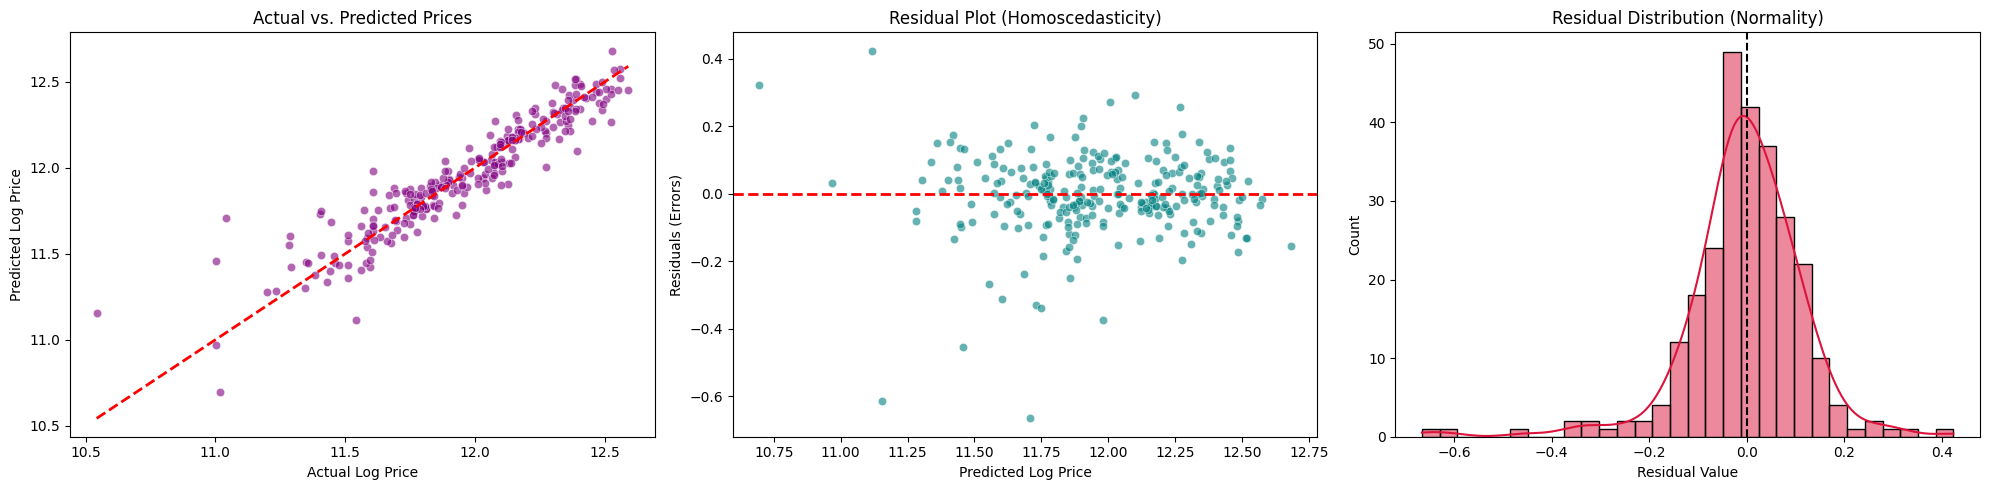

In [28]:
predictions = best_model.predict(X_test_processed)
residuals = y_test - predictions

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Plot 1: Actual vs Predicted Prices
sns.scatterplot(x=y_test, y=predictions, ax=axes[0], alpha=0.6, color="purple")
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_title("Actual vs. Predicted Prices")
axes[0].set_xlabel("Actual Log Price")
axes[0].set_ylabel("Predicted Log Price")

# Plot 2: Residual Plot (Errors vs Predicted)
sns.scatterplot(x=predictions, y=residuals, ax=axes[1], alpha=0.6, color="teal")
axes[1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1].set_title("Residual Plot (Homoscedasticity)")
axes[1].set_xlabel("Predicted Log Price")
axes[1].set_ylabel("Residuals (Errors)")

# Plot 3: Distribution of Residuals (Errors)
sns.histplot(residuals, kde=True, ax=axes[2], color="crimson", bins=30)
axes[2].axvline(x=0, color='black', linestyle='--')
axes[2].set_title("Residual Distribution (Normality)")
axes[2].set_xlabel("Residual Value")

plt.tight_layout()
plt.show()